In [31]:
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from model import GalerkinSARIMA
import time
import warnings


In [32]:

warnings.filterwarnings("ignore")
np.random.seed(123)

csv_path = "GDP.csv"
target_col = "GDP"
m_seasonal = 4

def _pick_date_col(df: pd.DataFrame) -> str:
    for c in ["observation_date", "GDP"]:
        if c in df.columns:
            return c
    return df.columns[0]

def _to_stationary(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    if (x > 0).all():
        return (100.0 * np.log(x)).diff().dropna()
    else:
        return x.diff().dropna()


def arima_rolling_prediction_intervals(train, n_forecast, actuals=None, order=(0, 0, 0), seasonal_order=(0, 0, 0, 1), alpha=0.05):
    """Rolling forecast with Mean CI for statsmodels ARIMA/SARIMA.
    Uses get_forecast().conf_int() which returns forecast mean CI (conditional mean), NOT obs-level PI.
    When reporting, label as 'Mean CI' not 'PI'. See docs/IMPLEMENTATION.md."""
    train = np.asarray(train, dtype=float)
    forecasts = np.zeros(n_forecast)
    pi_lower = np.zeros(n_forecast)
    pi_upper = np.zeros(n_forecast)
    ci_lower = np.zeros(n_forecast)
    ci_upper = np.zeros(n_forecast)
    hist = list(train)
    use_actuals = actuals is not None and len(actuals) >= n_forecast
    # When P=0 and Q=0, use (0,0,0,1) to avoid statsmodels issues with seasonal period
    P, D, Q, m = seasonal_order
    so = (0, 0, 0, 1) if (P == 0 and Q == 0) else seasonal_order
    for i in range(n_forecast):
        try:
            model = ARIMA(hist, order=order, seasonal_order=so)
            fit = model.fit(method_kwargs={"warn_convergence": False})
            f = fit.get_forecast(steps=1)
            pred = float(f.predicted_mean.iloc[0])
            forecasts[i] = pred
            ci = f.conf_int(alpha=alpha)
            # conf_int returns forecast mean CI (not obs PI); we use it for both pi/ci outputs
            pi_lower[i] = float(ci.iloc[0, 0])
            pi_upper[i] = float(ci.iloc[0, 1])
            ci_lower[i] = pi_lower[i]
            ci_upper[i] = pi_upper[i]
        except Exception:
            pred = float(hist[-1])
            forecasts[i] = pred
            # Fallback: use volatility-based 95% PI when fit fails (avoids 0 width / 0 coverage)
            hist_arr = np.array(hist)
            vol = np.std(hist_arr[-min(20, len(hist_arr)):]) if len(hist) > 1 else 1e-6
            vol = max(float(vol), 1e-6)
            half = 1.96 * vol
            pi_lower[i] = pred - half
            pi_upper[i] = pred + half
            ci_lower[i] = pi_lower[i]
            ci_upper[i] = pi_upper[i]
        hist.append(actuals[i] if use_actuals else forecasts[i])
    return {'forecasts': forecasts, 'pi_lower': pi_lower, 'pi_upper': pi_upper, 'ci_lower': ci_lower, 'ci_upper': ci_upper}

In [33]:

raw = pd.read_csv(csv_path)
date_col = _pick_date_col(raw)
raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")
raw = raw.set_index(date_col).sort_index()

if target_col not in raw.columns:
    numeric_cols = raw.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_cols:
        raise ValueError("No numeric columns found in FRED.csv.")
    target_col = numeric_cols[3]

y_level = raw[target_col].dropna()
y = _to_stationary(y_level).replace([np.inf, -np.inf], np.nan).dropna()
series_fred = y.values

# Store the date index corresponding to the series (after differencing/transformation)
# This will be used for plotting with dates on x-axis
date_index_fred = y.index

datasets = {f'FRED_{target_col}': series_fred}
date_indices = {f'FRED_{target_col}': date_index_fred}

In [34]:
window = 60   # Initial training window
horizon = 120  # Test period (rolling forecast length)
forecast_steps = 1

# Order grid for BIC model selection (each model selects its own best)
# Search from 0 to 5
p_values = list(range(6))   # [0,1,2,3,4,5]
q_values = list(range(2))
P_values = list(range(6))
Q_values = list(range(2))
orders = [(p, q, P, Q) for p in p_values for q in q_values for P in P_values for Q in Q_values]

# Matched-structure orders for Table 2 (supplementary: same p,q for all models)
matched_orders = [(0, 0, 0, 0), (1, 0, 0, 0), (0, 1, 1, 1)]  # representative subset

for name, series in datasets.items():
    if len(series) < window + horizon:
        adjusted_horizon = max(24, len(series) - window)
        print(f"Warning: Adjusted horizon for {name} to {adjusted_horizon}")
        horizon = adjusted_horizon

In [35]:
algorithms = [
    {'name': 'GARIMA-OLS', 'use_ridge': False},
    {'name': 'GARIMA-Ridge', 'use_ridge': True, 'ridge_lambda_ar': 1.5, 'ridge_lambda_ma': 1.0, 
     'ridge_weight_scheme': 'poly', 'ridge_eta': 1.5},
    {'name': 'ARIMA', 'is_statsmodels': True},
]

# ========== PHASE 1: BIC Model Selection (each model selects its own best order) ==========
best_order_per_alg = {}  # {alg_name: (p,q,P,Q)}
for name, series in datasets.items():
    n = len(series)
    test_start_idx = n - horizon
    train_start = max(0, test_start_idx - window)
    train = series[train_start:test_start_idx]
    m = m_seasonal
    for alg_config in algorithms:
        alg_name = alg_config['name']
        best_bic = np.inf
        best_ord = (0, 0, 0, 0)
        for p, q, P, Q in tqdm(orders, desc=f"BIC search {alg_name}", leave=False):
            try:
                if alg_config.get('is_statsmodels', False):
                    mod = ARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m))
                    fit = mod.fit(method_kwargs={"warn_convergence": False})
                    bic = fit.bic
                else:
                    model = GalerkinSARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m),
                        basis_functions=["quadratic", "sigmoid", "linear"], forecast_method="direct",
                        use_ridge=alg_config['use_ridge'], ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 2.0),
                        ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 2.0),
                        ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                        ridge_eta=alg_config.get('ridge_eta', 1.0), standardize=True)
                    model.fit(train)
                    bic = model.bic()
                if bic < best_bic:
                    best_bic = bic
                    best_ord = (p, q, P, Q)
            except Exception:
                pass
        best_order_per_alg[alg_name] = best_ord
        print(f"  {alg_name}: best order (p,q,P,Q)={best_ord} (BIC={best_bic:.2f})")

# ========== PHASE 2: Rolling Forecast at Best Order (fair tuned comparison) ==========
tuned_results = []
first_run_preds = {}
for name, series in datasets.items():
    m = m_seasonal
    n = len(series)
    test_start_idx = n - horizon
    test_end_idx = n
    y_true = series[test_start_idx:test_end_idx]
    for alg_config in algorithms:
        alg_name = alg_config['name']
        p, q, P, Q = best_order_per_alg[alg_name]
        preds, iter_times = [], []
        combo_start = time.perf_counter()
        for test_idx in range(test_start_idx, test_end_idx):
            t0 = time.perf_counter()
            train_start_idx = max(0, test_idx - window)
            train = series[train_start_idx:test_idx]
            try:
                if alg_config.get('is_statsmodels', False):
                    mod = ARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m))
                    fit = mod.fit(method_kwargs={"warn_convergence": False})
                    pred = float(fit.forecast(steps=forecast_steps)[-1])
                else:
                    model = GalerkinSARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m),
                        basis_functions=["quadratic", "sigmoid", "linear"], forecast_method="direct",
                        use_ridge=alg_config['use_ridge'], ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 2.0),
                        ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 2.0),
                        ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                        ridge_eta=alg_config.get('ridge_eta', 1.0), standardize=True)
                    model.fit(train)
                    pv = model.forecast(steps=forecast_steps)
                    pred = pv[-1] if np.ndim(pv) > 0 else float(pv)
                preds.append(float(pred))
            except Exception:
                preds.append(float(train[-1]))
            iter_times.append(time.perf_counter() - t0)
        preds = np.asarray(preds)
        combo_sec = time.perf_counter() - combo_start
        first_run_preds[(name, p, q, P, Q, alg_name)] = preds
        mae = mean_absolute_error(y_true, preds)
        rmse = np.sqrt(mean_squared_error(y_true, preds))
        err_var = np.var(y_true - preds)
        tuned_results.append({'Dataset': name, 'Alg': alg_name, 'Best_order': f"({p},{q},{P},{Q})",
            'MAE': mae, 'RMSE': rmse, 'MSE': rmse**2, 'Runtime_sec': combo_sec, 'Error_var': err_var, 'preds': preds})

# ========== PHASE 2b: Matched Structure (same p,q for all - supplementary Table 2) ==========
matched_results = []
for name, series in datasets.items():
    m, n = m_seasonal, len(series)
    test_start_idx, test_end_idx = n - horizon, n
    y_true = series[test_start_idx:test_end_idx]
    for p, q, P, Q in matched_orders:
        for alg_config in algorithms:
            alg_name = alg_config['name']
            preds = []
            for test_idx in range(test_start_idx, test_end_idx):
                train = series[max(0, test_idx - window):test_idx]
                try:
                    if alg_config.get('is_statsmodels', False):
                        mod = ARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m))
                        pred = float(mod.fit(method_kwargs={"warn_convergence": False}).forecast(steps=1)[-1])
                    else:
                        model = GalerkinSARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m),
                            basis_functions=["quadratic", "sigmoid", "linear"], forecast_method="direct",
                            use_ridge=alg_config['use_ridge'], ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 2.0),
                            ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 2.0),
                            ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                            ridge_eta=alg_config.get('ridge_eta', 1.0), standardize=True)
                        model.fit(train)
                        pv = model.forecast(steps=1)
                        pred = pv[-1] if np.ndim(pv) > 0 else float(pv)
                    preds.append(float(pred))
                except Exception:
                    preds.append(float(train[-1]))
            preds = np.asarray(preds)
            mse = mean_squared_error(y_true, preds)
            matched_results.append({'p,q,P,Q': f"({p},{q},{P},{Q})", 'Alg': alg_name, 'MSE': mse})

# Build df for backward compatibility with plotting cells
all_results = []
for r in tuned_results:
    p, q, P, Q = best_order_per_alg[r['Alg']]
    all_results.append([r['Dataset'], p, q, P, Q, 1, r['Alg'], r['MAE'], r['RMSE'],
        np.nan, np.nan, np.nan, r['Runtime_sec'], horizon, horizon/r['Runtime_sec']])
df = pd.DataFrame(all_results, columns=['Dataset','p','q','P','Q','Run','Alg','MAE','RMSE',
    'mean_iter_ms','median_iter_ms','max_iter_ms','combo_sec','num_iters','throughput_iters_per_sec'])
agg = df.groupby(['Dataset','p','q','P','Q','Alg'], as_index=False).mean(numeric_only=True)
print("\n=== TABLE 1: Tuned Performance (each model at its BIC-best order) ===")
tuned_df = pd.DataFrame(tuned_results)
for c in ['MAE','RMSE','Runtime_sec','Error_var']:
    if c in tuned_df.columns:
        tuned_df[c] = pd.to_numeric(tuned_df[c], errors='coerce')
print(tuned_df[['Alg','Best_order','MAE','RMSE','Runtime_sec']].to_string(index=False))
print("\n=== TABLE 3: Stability (variance of forecast errors) ===")
print(tuned_df[['Alg','Error_var']].to_string(index=False))
print("\n=== TABLE 2: Matched Structure (same p,q for all - supplementary) ===")
match_df = pd.DataFrame(matched_results)
print(match_df.pivot(index='p,q,P,Q', columns='Alg', values='MSE').to_string())
print("\nLegacy agg (for plotting):")
try:
    print(agg.to_markdown(index=False, floatfmt=".4f"))
except Exception:
    print(agg)

  GARIMA-OLS: best order (p,q,P,Q)=(0, 0, 1, 0) (BIC=-0.23)


  GARIMA-Ridge: best order (p,q,P,Q)=(0, 0, 1, 0) (BIC=-0.10)


  ARIMA: best order (p,q,P,Q)=(1, 0, 0, 0) (BIC=151.88)

=== TABLE 1: Tuned Performance (each model at its BIC-best order) ===
         Alg Best_order      MAE     RMSE  Runtime_sec
  GARIMA-OLS  (0,0,1,0) 1.222341 4.637936     0.042457
GARIMA-Ridge  (0,0,1,0) 0.685514 1.391117     0.048906
       ARIMA  (1,0,0,0) 0.737726 1.818643     0.902376

=== TABLE 3: Stability (variance of forecast errors) ===
         Alg  Error_var
  GARIMA-OLS  21.415492
GARIMA-Ridge   1.934747
       ARIMA   3.291518

=== TABLE 2: Matched Structure (same p,q for all - supplementary) ===
Alg           ARIMA  GARIMA-OLS  GARIMA-Ridge
p,q,P,Q                                      
(0,0,0,0)  1.813246    1.813246      1.813246
(0,1,1,1)  2.896179   39.749263      7.400853
(1,0,0,0)  3.307461   26.486815      5.084806

Legacy agg (for plotting):
| Dataset   |   p |   q |   P |   Q | Alg          |    Run |    MAE |   RMSE |   mean_iter_ms |   median_iter_ms |   max_iter_ms |   combo_sec |   num_iters |   throughp

In [36]:
# Tuned results (each model at its BIC-best order)
pd.DataFrame(tuned_results)[['Alg', 'Best_order', 'MAE', 'RMSE', 'Runtime_sec']]

,Alg,Best_order,MAE,RMSE,Runtime_sec
0,GARIMA-OLS,"(0,0,1,0)",1.222341,4.637936,0.042457
1,GARIMA-Ridge,"(0,0,1,0)",0.685514,1.391117,0.048906
2,ARIMA,"(1,0,0,0)",0.737726,1.818643,0.902376


Saved: GDP_comparison_plots/FRED_GDP_tuned_comparison.png


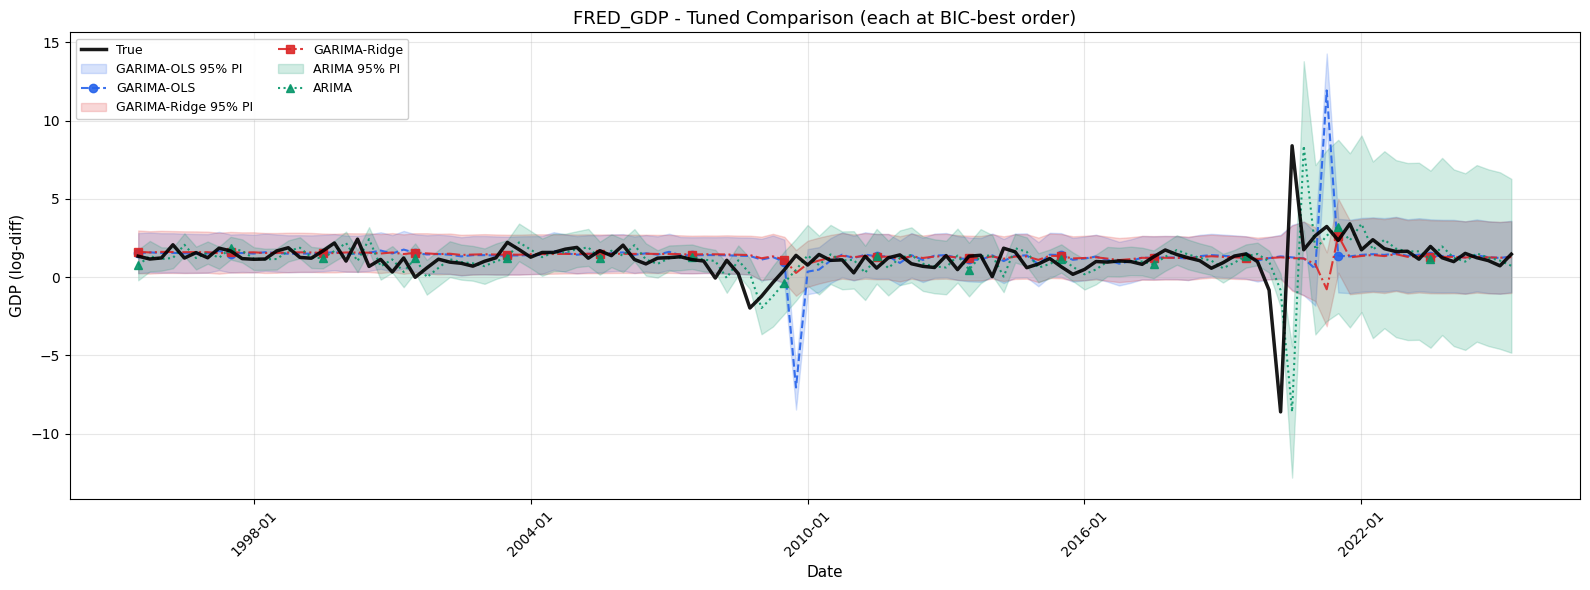

In [37]:
import os
import matplotlib.dates as mdates

# Create folder for plots if it doesn't exist
plot_dir = "GDP_comparison_plots"
os.makedirs(plot_dir, exist_ok=True)

# Plot comparison: each algorithm at its BIC-best order
for name, series in datasets.items():
    n = len(series)
    test_start_idx = n - horizon
    test_end_idx = n
    date_index = date_indices[name]
    test_dates = date_index[test_start_idx:test_end_idx]
    y_true = series[test_start_idx:test_end_idx]
    
    # One plot per dataset: all algorithms at their best order
    plt.figure(figsize=(16, 6))
    # True data: thick black line, on top for visibility
    plt.plot(test_dates, y_true, 'k-', linewidth=2.5, label='True', alpha=0.9, zorder=10)
    colors = {'GARIMA-OLS': '#2563eb', 'GARIMA-Ridge': '#dc2626', 'ARIMA': '#059669'}
    markers = {'GARIMA-OLS': 'o', 'GARIMA-Ridge': 's', 'ARIMA': '^'}
    linestyles = {'GARIMA-OLS': '--', 'GARIMA-Ridge': '-.', 'ARIMA': ':'}
    for alg_name in ['GARIMA-OLS', 'GARIMA-Ridge', 'ARIMA']:
        p, q, P, Q = best_order_per_alg[alg_name]
        key = (name, p, q, P, Q, alg_name)
        train_start = max(0, test_start_idx - window)
        train = series[train_start:test_start_idx]
        try:
            if alg_name == 'ARIMA':
                roll = arima_rolling_prediction_intervals(train, horizon, actuals=y_true, order=(p, 0, q), seasonal_order=(P, 0, Q, m_seasonal), alpha=0.05)
            else:
                alg_config = next((a for a in algorithms if a['name'] == alg_name), None)
                if alg_config is None:
                    continue
                model = GalerkinSARIMA(order=(p, 0, q), seasonal_order=(P, 0, Q, m_seasonal),
                    basis_functions=["quadratic", "sigmoid", "linear"], forecast_method="direct",
                    use_ridge=alg_config['use_ridge'], ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 1.0),
                    ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 1.0),
                    ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                    ridge_eta=alg_config.get('ridge_eta', 1.0), standardize=True)
                roll = model.rolling_prediction_intervals(train, horizon, actuals=y_true, method='residual', alpha=0.05)
            preds = roll['forecasts']
            # Each model: PI shaded area + forecast line, with model-specific legend
            interval_label = f'{alg_name} 95% Mean CI' if alg_name == 'ARIMA' else f'{alg_name} 95% PI'
            plt.fill_between(test_dates, roll['pi_lower'], roll['pi_upper'], alpha=0.18, color=colors[alg_name], label=interval_label)
            plt.plot(test_dates, preds, color=colors[alg_name], linestyle=linestyles[alg_name],
                    marker=markers[alg_name], markevery=max(1, horizon//15), label=alg_name, linewidth=1.5, alpha=0.9)
        except Exception as e:
            if key in first_run_preds:
                plt.plot(test_dates, first_run_preds[key], color=colors[alg_name], linestyle=linestyles[alg_name],
                        marker=markers[alg_name], markevery=max(1, horizon//15), label=alg_name, linewidth=1.5, alpha=0.9)
    
    plt.title(f"{name} - Tuned Comparison (each at BIC-best order)", fontsize=13)
    plt.xlabel("Date", fontsize=11)
    plt.ylabel("GDP (log-diff)", fontsize=11)
    plt.legend(loc='upper left', ncol=2, fontsize=9, framealpha=0.95)
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=max(1, horizon//20)))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plot_filename = f"{plot_dir}/{name}_tuned_comparison.png"
    plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
    print(f"Saved: {plot_filename}")
    plt.show()

SUMMARY: Algorithm Comparison for GDP Forecasting

Overall Performance (Tuned: each model at its BIC-best order):
         Alg      MAE     RMSE  combo_sec
GARIMA-Ridge 0.685514 1.391117   0.048906
       ARIMA 0.737726 1.818643   0.902376
  GARIMA-OLS 1.222341 4.637936   0.042457

Saved summary table to: GDP_results/summary_comparison.txt

Best Algorithm Per Dataset (by RMSE):

FRED_GDP:
  Best algorithm: GARIMA-Ridge
  MAE: 0.6855, RMSE: 1.3911
  All algorithms (sorted by RMSE):
    GARIMA-Ridge   : MAE=0.6855, RMSE=1.3911 ✓ (Winner)
    ARIMA          : MAE=0.7377, RMSE=1.8186   (+30.7% worse)
    GARIMA-OLS     : MAE=1.2223, RMSE=4.6379   (+233.4% worse)

Saved comparison plot to: GDP_results/algorithm_comparison.png


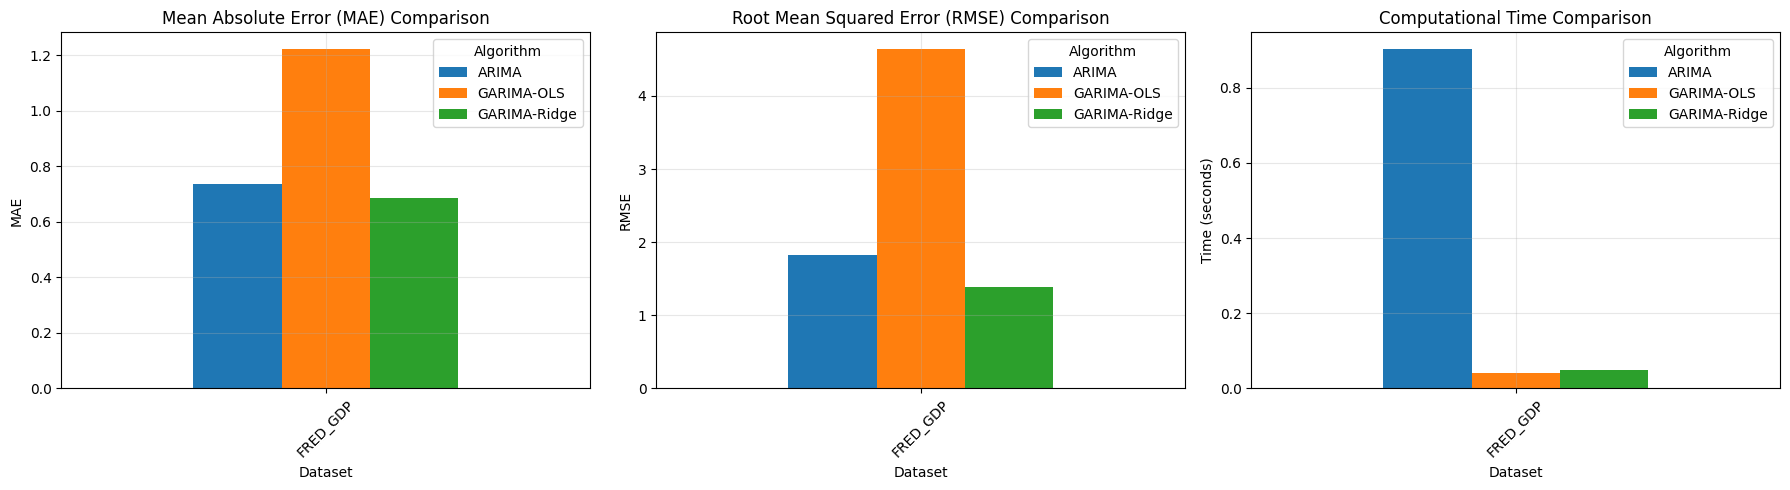


Computational Efficiency:
         Alg  mean_iter_ms  combo_sec  throughput_iters_per_sec
  GARIMA-OLS           NaN   0.042457               2826.400102
GARIMA-Ridge           NaN   0.048906               2453.665744
       ARIMA           NaN   0.902376                132.982315

Saved timing comparison to: GDP_results/timing_comparison.txt


In [38]:
import os

# Summary comparison across all algorithms
print("="*70)
print("SUMMARY: Algorithm Comparison for GDP Forecasting")
print("="*70)

# Check if df exists (from Cell 4)
if 'df' not in locals() and 'df' not in globals():
    raise ValueError("Error: 'df' variable not found. Please run Cell 4 first to create the results DataFrame.")

# Overall average across all datasets
overall = df.groupby('Alg', as_index=False)[['MAE', 'RMSE', 'combo_sec']].mean()
overall = overall.sort_values('RMSE')

print("\nOverall Performance (Tuned: each model at its BIC-best order):")
print(overall.to_string(index=False))

# Save results to GDP-specific directory
results_dir = "GDP_results"
os.makedirs(results_dir, exist_ok=True)

with open(f"{results_dir}/summary_comparison.txt", 'w') as f:
    f.write("Overall Performance (averaged across all datasets and parameter combinations):\n")
    f.write("="*70 + "\n")
    f.write(overall.to_string(index=False))
print(f"\nSaved summary table to: {results_dir}/summary_comparison.txt")

# Best performer per dataset
print("\n" + "="*70)
print("Best Algorithm Per Dataset (by RMSE):")
print("="*70)

for dataset in df['Dataset'].unique():
    dataset_df = df[df['Dataset'] == dataset]
    best = dataset_df.groupby('Alg', as_index=False)[['MAE', 'RMSE']].mean()
    best = best.sort_values('RMSE')
    winner = best.iloc[0]
    
    print(f"\n{dataset}:")
    print(f"  Best algorithm: {winner['Alg']}")
    print(f"  MAE: {winner['MAE']:.4f}, RMSE: {winner['RMSE']:.4f}")
    print(f"  All algorithms (sorted by RMSE):")
    for _, row in best.iterrows():
        # Calculate percentage difference from winner
        if row['Alg'] == winner['Alg']:
            status = "✓ (Winner)"
        else:
            diff_pct = ((row['RMSE'] - winner['RMSE']) / winner['RMSE']) * 100
            status = f"  (+{diff_pct:.1f}% worse)"
        print(f"    {row['Alg']:15s}: MAE={row['MAE']:.4f}, RMSE={row['RMSE']:.4f} {status}")

# Create bar plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE comparison
mae_pivot = df.groupby(['Dataset', 'Alg'])['MAE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='MAE'
)
mae_pivot.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Mean Absolute Error (MAE) Comparison')
axes[0].set_ylabel('MAE')
axes[0].legend(title='Algorithm', loc='best')
axes[0].grid(True, alpha=0.3)

# RMSE comparison
rmse_pivot = df.groupby(['Dataset', 'Alg'])['RMSE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='RMSE'
)
rmse_pivot.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Root Mean Squared Error (RMSE) Comparison')
axes[1].set_ylabel('RMSE')
axes[1].legend(title='Algorithm', loc='best')
axes[1].grid(True, alpha=0.3)

# Timing comparison (computational efficiency)
timing_pivot = df.groupby(['Dataset', 'Alg'])['combo_sec'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='combo_sec'
)
timing_pivot.plot(kind='bar', ax=axes[2], rot=45)
axes[2].set_title('Computational Time Comparison')
axes[2].set_ylabel('Time (seconds)')
axes[2].legend(title='Algorithm', loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save the comparison plot
comparison_plot_path = f"{results_dir}/algorithm_comparison.png"
plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
print(f"\nSaved comparison plot to: {comparison_plot_path}")
plt.show()

# Timing comparison
print("\n" + "="*70)
print("Computational Efficiency:")
print("="*70)
timing = df.groupby('Alg', as_index=False)[['mean_iter_ms', 'combo_sec', 'throughput_iters_per_sec']].mean()
timing = timing.sort_values('combo_sec')
print(timing.to_string(index=False))

# Save timing comparison
with open(f"{results_dir}/timing_comparison.txt", 'w') as f:
    f.write("Computational Efficiency (averaged across all runs and parameter combinations):\n")
    f.write("="*70 + "\n")
    f.write(timing.to_string(index=False))
print(f"\nSaved timing comparison to: {results_dir}/timing_comparison.txt")


In [41]:
# =============================================================================
# PAPER-READY SUMMARY STATISTICS
# =============================================================================
# Tables suitable for inclusion in a research paper

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (avoid div by zero)."""
    mask = np.abs(y_true) > 1e-10
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    """Symmetric MAPE."""
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom > 1e-10
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def pi_coverage(y_true, pi_lo, pi_hi):
    """Fraction of actuals falling within 95% prediction interval."""
    inside = (y_true >= pi_lo) & (y_true <= pi_hi)
    return np.mean(inside) * 100

def mean_interval_width(pi_lo, pi_hi):
    """Average width of prediction interval."""
    return np.mean(pi_hi - pi_lo)

# Compute metrics for each algorithm at its BIC-best order
paper_stats = []
for name, series in datasets.items():
    n = len(series)
    test_start_idx = n - horizon
    test_end_idx = n
    y_true = series[test_start_idx:test_end_idx]
    train_start = max(0, test_start_idx - window)
    train = series[train_start:test_start_idx]
    
    for alg_name in ['ARIMA', 'GARIMA-OLS', 'GARIMA-Ridge']:
        p, q, P, Q = best_order_per_alg[alg_name]
        key = (name, p, q, P, Q, alg_name)
        if key not in first_run_preds:
            continue
        preds = np.array(first_run_preds[key])
        mae = mean_absolute_error(y_true, preds)
        rmse = np.sqrt(mean_squared_error(y_true, preds))
        mape_val = mape(y_true, preds)
        smape_val = smape(y_true, preds)
        try:
            if alg_name == 'ARIMA':
                roll = arima_rolling_prediction_intervals(train, horizon, actuals=y_true, order=(p, 0, q), seasonal_order=(P, 0, Q, m_seasonal), alpha=0.05)
            else:
                alg_config = next((a for a in algorithms if a['name'] == alg_name), None)
                model = GalerkinSARIMA(order=(p, 0, q), seasonal_order=(P, 0, Q, m_seasonal),
                    basis_functions=["quadratic", "sigmoid", "linear"], forecast_method="direct",
                    use_ridge=alg_config['use_ridge'], ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 1.0),
                    ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 1.0),
                    ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                    ridge_eta=alg_config.get('ridge_eta', 1.0), standardize=True)
                roll = model.rolling_prediction_intervals(train, horizon, actuals=y_true, method='residual', alpha=0.05)
            cov = pi_coverage(y_true, roll['pi_lower'], roll['pi_upper'])
            width = mean_interval_width(roll['pi_lower'], roll['pi_upper'])
        except Exception:
            cov = np.nan
            width = np.nan
        paper_stats.append({
            'Dataset': name, 'p': p, 'q': q, 'P': P, 'Q': Q, 'Alg': alg_name,
            'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val, 'sMAPE': smape_val,
            'PI_Coverage_%': cov, 'Mean_PI_Width': width
        })

ps_df = pd.DataFrame(paper_stats)

# Table 1: Forecast accuracy by algorithm (averaged over orders)
print("="*80)
print("TABLE 1: Forecast Accuracy by Algorithm (GDP, tuned, rolling 1-step, horizon={})".format(horizon))
print("="*80)
acc = ps_df.groupby('Alg').agg({'MAE': 'mean', 'RMSE': 'mean', 'MAPE': 'mean', 'sMAPE': 'mean'}).round(4)
print(acc.to_string())
print()

# Table 2: Interval quality (ARIMA: Mean CI; GARIMA: PI)
print("="*80)
print("TABLE 2: 95% Interval Quality (ARIMA=Mean CI, GARIMA=PI)")
print("="*80)
pi_qual = ps_df.groupby('Alg').agg({'PI_Coverage_%': 'mean', 'Mean_PI_Width': 'mean'}).round(2)
print(pi_qual.to_string())
print()

# Table 3: Best model per algorithm (by RMSE)
print("="*80)
print("TABLE 3: Order (p,q,P,Q) per Algorithm (selected by BIC)")
print("="*80)
best_per_alg = ps_df.loc[ps_df.groupby('Alg')['RMSE'].idxmin()]
for _, row in best_per_alg.iterrows():
    print(f"  {row['Alg']:15s}: ({row['p']},{row['q']},{row['P']},{row['Q']})  MAE={row['MAE']:.4f}  RMSE={row['RMSE']:.4f}  Coverage={row['PI_Coverage_%']:.1f}%")
print()

# LaTeX table for paper
print("="*80)
print("LATEX TABLE (copy to paper):")
print("="*80)
latex_acc = acc.reset_index()
latex_str = "\\\\\n".join([f"{row['Alg']} & {row['MAE']:.4f} & {row['RMSE']:.4f} & {row['MAPE']:.2f} & {row['sMAPE']:.2f}" for _, row in latex_acc.iterrows()])
print("\\begin{table}[htbp]")
print("\\caption{Forecast accuracy on FRED GDP. Tuned (BIC-best order per model). Rolling 1-step, horizon=" + str(horizon) + ".}")
print("\\begin{tabular}{lcccc}")
print("\\hline")
print("Algorithm & MAE & RMSE & MAPE (\\%) & sMAPE (\\%) \\\\")
print("\\hline")
print(latex_str + " \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")

# Save to file
results_dir = "GDP_results"
os.makedirs(results_dir, exist_ok=True)
with open(f"{results_dir}/paper_summary_stats.txt", 'w') as f:
    f.write("Forecast Accuracy:\n")
    f.write(acc.to_string() + "\n\n")
    f.write("PI Quality:\n")
    f.write(pi_qual.to_string() + "\n")
print(f"\nSaved to {results_dir}/paper_summary_stats.txt")

TABLE 1: Forecast Accuracy by Algorithm (GDP, tuned, rolling 1-step, horizon=120)
                 MAE    RMSE      MAPE    sMAPE
Alg                                            
ARIMA         0.7377  1.8186  223.6699  49.9575
GARIMA-OLS    1.2223  4.6379  257.6029  53.7063
GARIMA-Ridge  0.6855  1.3911  217.0717  49.8839

TABLE 2: 95% Prediction Interval Quality
              PI_Coverage_%  Mean_PI_Width
Alg                                       
ARIMA                 86.67           3.66
GARIMA-OLS            90.83           2.92
GARIMA-Ridge          91.67           3.00

TABLE 3: Order (p,q,P,Q) per Algorithm (selected by BIC)
  ARIMA          : (1,0,0,0)  MAE=0.7377  RMSE=1.8186  Coverage=86.7%
  GARIMA-OLS     : (0,0,1,0)  MAE=1.2223  RMSE=4.6379  Coverage=90.8%
  GARIMA-Ridge   : (0,0,1,0)  MAE=0.6855  RMSE=1.3911  Coverage=91.7%

LATEX TABLE (copy to paper):
\begin{table}[htbp]
\caption{Forecast accuracy on FRED GDP. Tuned (BIC-best order per model). Rolling 1-step, horizon=120.}

In [40]:
# ========== Model Summary: Variable Significance & Statistics ==========
# Fit each model at its BIC-best order on the final training window and print summary
for name, series in datasets.items():
    n = len(series)
    test_start_idx = n - horizon
    train_start = max(0, test_start_idx - window)
    train = series[train_start:test_start_idx]
    train = np.asarray(train, dtype=float)
    m = m_seasonal

    for cfg in algorithms:
        alg_name = cfg['name']
        if alg_name not in best_order_per_alg:
            continue
        p, q, P, Q = best_order_per_alg[alg_name]
        print("=" * 80)
        print(f"MODEL SUMMARY: {alg_name}  |  order (p,q,P,Q)=({p},{q},{P},{Q})")
        print("=" * 80)

        if cfg.get('is_statsmodels'):
            # ARIMA: statsmodels fit.summary() gives coefficients, std err, t-stats, p-values, AIC, BIC, Ljung-Box
            order = (p, 0, q)
            try:
                if P == 0 and Q == 0:
                    # No seasonal: use non-seasonal ARIMA (statsmodels rejects m=1)
                    arima_model = ARIMA(train, order=order)
                else:
                    arima_model = ARIMA(train, order=order, seasonal_order=(P, 0, Q, m))
                arima_fit = arima_model.fit(method_kwargs={"warn_convergence": False})
                print(arima_fit.summary())
            except Exception as e:
                print(f"ARIMA fit failed: {e}")
        else:
            # GARIMA-OLS / GARIMA-Ridge: model.summary() gives coefficients, bootstrap SE, t-stats, p-values, R², BIC
            model = GalerkinSARIMA(
                order=(p, 0, q), seasonal_order=(P, 0, Q, m),
                use_ridge=cfg.get('use_ridge', False),
                ridge_lambda_ar=cfg.get('ridge_lambda_ar', 1.0),
                ridge_lambda_ma=cfg.get('ridge_lambda_ma', 1.0),
                ridge_weight_scheme=cfg.get('ridge_weight_scheme', 'poly'),
                ridge_eta=cfg.get('ridge_eta', 1.0),
            )
            # n_bootstrap=100 for faster execution; increase for publication
            summary = model.summary(train, n_bootstrap=100, random_state=123)
            print(summary)
        print()

MODEL SUMMARY: GARIMA-OLS  |  order (p,q,P,Q)=(0,0,1,0)
Call:
  GalerkinSARIMA(order=(0, 0, 0), seasonal_order=(1, 0, 0, 4))

Residuals:
     Min       1Q   Median       3Q      Max
  -1.8148   -0.4823   -0.0746    0.3569    1.5329

Coefficients:
                    Estimate   Std. Error    t value     Pr(>|t|)
-----------------------------------------------------------------
AR_b1                 0.8672       0.1522     5.6975     0.0000 ***
AR_b2                -0.1019       0.1515    -0.6727     0.5011  
-----------------------------------------------------------------

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.7121 on 54 degrees of freedom
Multiple R-squared:  0.01604,	Adjusted R-squared: -0.00218
F-statistic: 0.4401 on 2 and 54 DF,  p-value: 0.6462
BIC: -0.4998

MODEL SUMMARY: GARIMA-Ridge  |  order (p,q,P,Q)=(0,0,1,0)
Call:
  GalerkinSARIMA(order=(0, 0, 0), seasonal_order=(1, 0, 0, 4))

Residuals:
     Min       1Q   Median       3